Question: Which fitness content types recieve the most views, and which engagement metrics are most closely correlated with views?

I recorded the metrics of 172 instagram reels from my OwenFit account, posted March-August 2026.

Comparing the mean and median views by content type, and calculating Spearman correlations for nine reel metrics.

In [1]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving OwenFit Engagement Data-2.xlsx to OwenFit Engagement Data-2.xlsx


In [2]:
filename = next(iter(uploaded))

# Read the data columns, excluding the category key in column U.
df = pd.read_excel(filename, usecols="A:T")

# Exclude Accounts Reached.
df = df.drop(columns="Accounts Reached")

df.head()

,Post ID,Date,Views,Skip Rate,Likes,Comments,Reposts,Shares,Saves,Avg. Watch Time,Follows,Length,Share Rate,Like Rate,Save Rate,Repost Rate,Comment Rate,Percent Watched,Type
0,1,2026-03-02,3148,0.493,120,7,4,6,5,8,0,15,0.002668,0.053357,0.002223,0.001779,0.003112,0.533333,P
1,2,2026-03-04,3412,0.341,96,8,0,6,17,8,2,17,0.002439,0.039024,0.006911,0.000000,0.003252,0.470588,L
2,3,2026-03-06,3537,0.423,142,5,4,7,15,7,1,12,0.002861,0.058030,0.006130,0.001635,0.002043,0.583333,P
3,4,2026-03-17,10546,0.355,657,16,33,96,101,10,7,17,0.013092,0.089595,0.013773,0.004500,0.002182,0.588235,E
4,5,2026-03-18,1797,0.594,82,2,0,6,6,6,3,15,0.004598,0.062835,0.004598,0.000000,0.001533,0.400000,P


,Posts,Median Views,Mean Views,Highest Views
Content Type,,,,
Other,2,11115.0,11115.0,19611
Transformation,2,5879.0,5879.0,9292
Talking,9,4907.0,149960.0,712101
Edit,19,4792.0,63617.0,683628
Funny,6,3864.0,55932.0,287007
Relatable,26,3779.0,11256.0,156948
Lifestyle,12,3477.0,4126.0,9144
Physique,81,2916.0,3326.0,17261
Gym,15,2896.0,3136.0,5837


172 reels | 3,586,594 recorded views


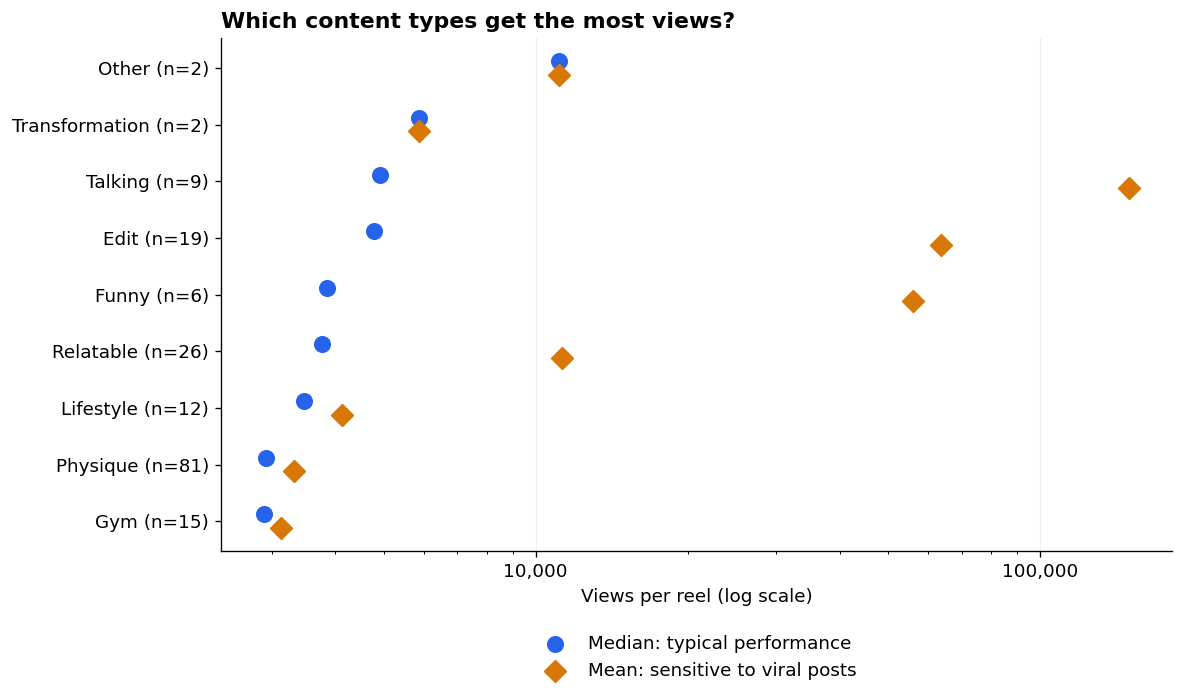

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

metrics = [
    "Skip Rate", "Length", "Share Rate", "Save Rate", "Like Rate",
    "Repost Rate", "Comment Rate", "Percent Watched", "Avg. Watch Time"
]

type_labels = {
    "P": "Physique", "L": "Lifestyle", "E": "Edit", "R": "Relatable",
    "TR": "Transformation", "TA": "Talking", "O": "Other",
    "F": "Funny", "G": "Gym"
}

# Work on a copy and preserve your existing engagement rates.
data = df.drop(columns="Accounts Reached", errors="ignore").copy()
data["Date"] = pd.to_datetime(data["Date"])
data["Content Type"] = data["Type"].str.strip().map(type_labels)
data = data.sort_values(["Date", "Post ID"]).reset_index(drop=True)

# Validate the inputs.
assert data[metrics + ["Views", "Content Type", "Date"]].notna().all().all(), "Check missing values or unknown content types."
assert np.isfinite(data[metrics + ["Views"]].to_numpy()).all(), "Check nonnumeric or infinite values."
assert (data["Views"] > 0).all(), "Views must be positive for the log model."
assert data["Post ID"].is_unique, "Check duplicate post IDs."

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 120
})

content_summary = data.groupby("Content Type").agg(**{
    "Posts": ("Post ID", "count"),
    "Median Views": ("Views", "median"),
    "Mean Views": ("Views", "mean"),
    "Highest Views": ("Views", "max")
}).sort_values("Median Views", ascending=False)

display(content_summary.round(0))
print(f"{len(data)} reels | {data['Views'].sum():,} recorded views")

fig, ax = plt.subplots(figsize=(10, 6))
positions = np.arange(len(content_summary))

ax.scatter(
    content_summary["Median Views"], positions - 0.12,
    s=85, color="#2563EB", label="Median: typical performance"
)
ax.scatter(
    content_summary["Mean Views"], positions + 0.12,
    s=85, marker="D", color="#D97706",
    label="Mean: sensitive to viral posts"
)

ax.set_yticks(positions)
ax.set_yticklabels([
    f"{name} (n={int(row['Posts'])})"
    for name, row in content_summary.iterrows()
])
ax.invert_yaxis()
ax.set_xscale("log")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Views per reel (log scale)")
ax.set_title(
    "Which content types get the most views?",
    loc="left", fontweight="bold"
)
ax.grid(axis="x", alpha=0.2)
ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.13), frameon=False
)
fig.tight_layout()
plt.show()

Talking videos have the highest mean views, while the median is somewhat average. This is due to the high-virality potential of the content type. The Other category had the highest median views, but this shouldn't be considered significant because there's only 2 videos to pull from. I should categorize those videos in the future anyways. Gym videos had the lowest median and mean.

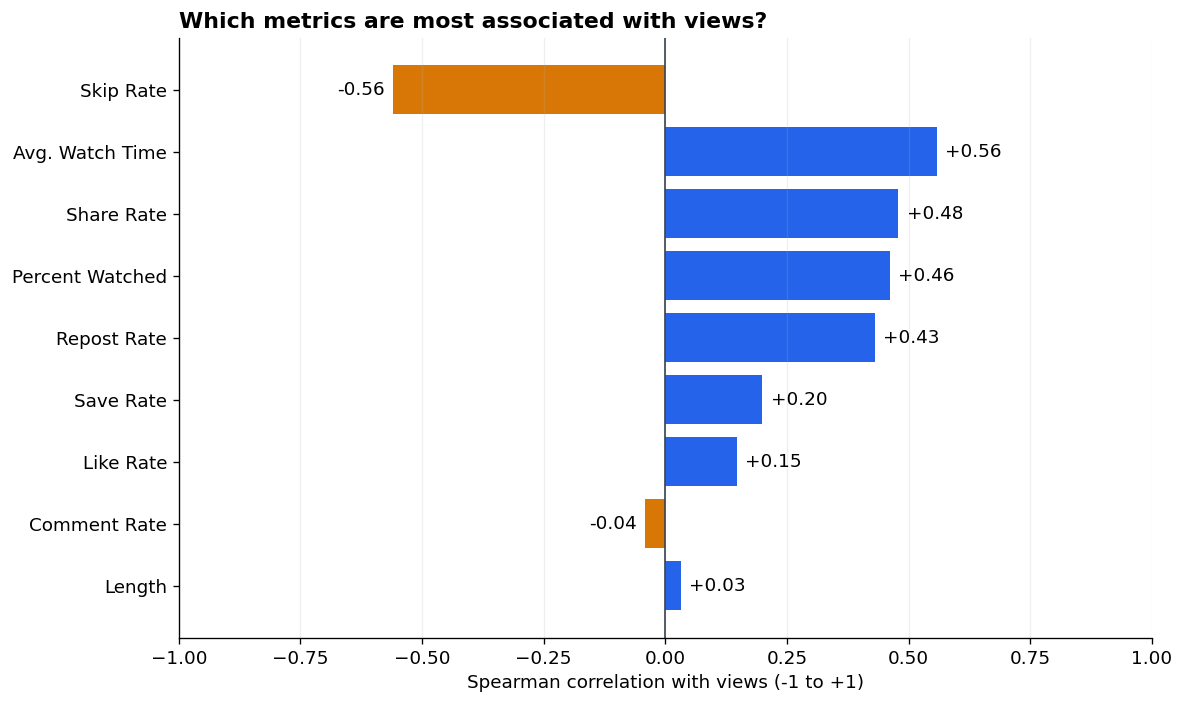

In [4]:
correlations = (
    data[metrics + ["Views"]].corr(method="spearman")["Views"]
    .drop("Views")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    "#2563EB" if value >= 0 else "#D97706"
    for value in correlations
]

bars = ax.barh(
    correlations.index, correlations.values, color=colors
)

ax.bar_label(
    bars,
    labels=[f"{value:+.2f}" for value in correlations],
    padding=5
)

ax.invert_yaxis()
ax.axvline(0, color="#374151", linewidth=1)
ax.set_xlim(-1, 1)
ax.set_xlabel("Spearman correlation with views (-1 to +1)")
ax.set_title(
    "Which metrics are most associated with views?",
    loc="left", fontweight="bold"
)
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
plt.show()

Skip rate and Average Watch Time had the exact same correlation with views, which surprised me a lot. Share rate is also very important. Length of the video seems to have almost no correlation, while comment rate has a negative correlation within my data. I'm guessing this is just coincidence with the data, but there may be some underlying reason to this.